# ShopSmart India — E-Commerce Customer Behaviour & A/B Testing Analysis

![Banner](https://images.unsplash.com/photo-1556742049-0cfed4f6a45d?w=1000)

## Project Overview

This project analyses 5,000 e-commerce orders from ShopSmart India 
to understand customer behaviour, spending patterns, and the impact 
of a checkout button A/B test on conversion rates.

The analysis covers:
- Delivery time validation against industry benchmark
- Spending behaviour across gender and cities
- Device type impact on conversion
- A/B test on checkout button colour change
- Statistical validation using hypothesis tests
- Business recommendations for the product and marketing team

## Dataset
- Source: ShopSmart India — Simulated E-Commerce Orders
- Total orders: 5,000
- Total features: 17 columns

## Tools Used
- Python (Pandas, NumPy, Matplotlib, Seaborn)
- SciPy & Statsmodels (Statistical Testing)
- Jupyter Notebook

## Key Business Questions
- Is our delivery time faster than the industry standard of 5 days?
- Do female customers spend more than male customers?
- Is average order value different across 5 cities?
- Does device type affect conversion rate?
- Did the new orange checkout button increase orders?

## Statistical Tests Performed

- **One-Sample T-Test** — Is our average delivery time different from the industry claim of 5 days?
- **Two-Sample T-Test** — Do female customers spend more per order than male customers?
- **ANOVA** — Is average order value different across Mumbai, Delhi, Bengaluru, Chennai and Hyderabad?
- **Chi-Square** — Does the device type a customer uses affect whether they convert or not?
- **Z-Test / A/B Test** — Did the new orange checkout button convert better than the old blue button?

In [4]:
# Load the dataset
import pandas as pd

df = pd.read_csv(r'C:\Users\LENOVO\OneDrive\Desktop\Python\Statistics\shopsmart_ecommerce.csv')
print(df.shape)
print(df.head())

(5000, 17)
   order_id customer_id       city  gender  age device_type traffic_source  \
0  ORD00001   CUST03175    Chennai    Male   22     Desktop     Google Ads   
1  ORD00002   CUST00861  Bengaluru  Female   59      Mobile     Google Ads   
2  ORD00003   CUST01295  Hyderabad    Male   25      Mobile     Google Ads   
3  ORD00004   CUST01131     Mumbai    Male   55      Tablet     Google Ads   
4  ORD00005   CUST01096      Delhi    Male   45     Desktop        Organic   

  experiment_group  converted  order_value  num_items  session_time_min  \
0        B_Variant          0         2149          2             18.05   
1        B_Variant          0         4361          3             10.05   
2        B_Variant          0         1362          2              5.06   
3        A_Control          0         3955          4              1.79   
4        A_Control          0         3171          2             18.10   

   delivery_time_days  customer_rating  discount_applied payment_meth

In [5]:
# check duplicates 
df.duplicated().sum()

np.int64(0)

In [6]:
# check duplicates of each column
df.apply(lambda x: x.duplicated().sum())

order_id                 0
customer_id           2398
city                  4995
gender                4998
age                   4958
device_type           4997
traffic_source        4995
experiment_group      4998
converted             4998
order_value           2607
num_items             4992
session_time_min      3524
delivery_time_days    4919
customer_rating       4968
discount_applied      4998
payment_method        4995
return_flag           4998
dtype: int64

In [7]:
# check nulls
df.isnull().sum()

order_id              0
customer_id           0
city                  0
gender                0
age                   0
device_type           0
traffic_source        0
experiment_group      0
converted             0
order_value           0
num_items             0
session_time_min      0
delivery_time_days    0
customer_rating       0
discount_applied      0
payment_method        0
return_flag           0
dtype: int64

In [8]:
# check dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            5000 non-null   object 
 1   customer_id         5000 non-null   object 
 2   city                5000 non-null   object 
 3   gender              5000 non-null   object 
 4   age                 5000 non-null   int64  
 5   device_type         5000 non-null   object 
 6   traffic_source      5000 non-null   object 
 7   experiment_group    5000 non-null   object 
 8   converted           5000 non-null   int64  
 9   order_value         5000 non-null   int64  
 10  num_items           5000 non-null   int64  
 11  session_time_min    5000 non-null   float64
 12  delivery_time_days  5000 non-null   float64
 13  customer_rating     5000 non-null   float64
 14  discount_applied    5000 non-null   int64  
 15  payment_method      5000 non-null   object 
 16  return

In [9]:
# check statistical summary

df.describe()

,age,converted,order_value,num_items,session_time_min,delivery_time_days,customer_rating,discount_applied,return_flag
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,38.411400,0.10420,3323.190400,3.020200,9.141446,4.295040,3.969420,0.383400,0.096600
std,12.176527,0.30555,753.304919,1.788751,3.773300,1.467313,0.605326,0.486263,0.295442
min,18.000000,0.00000,782.000000,1.000000,1.000000,1.000000,1.900000,0.000000,0.000000
25%,28.000000,0.00000,2815.000000,1.000000,6.537500,3.300000,3.500000,0.000000,0.000000
50%,38.000000,0.00000,3312.500000,3.000000,8.820000,4.300000,4.000000,0.000000,0.000000
75%,49.000000,0.00000,3819.000000,4.000000,11.410000,5.300000,4.400000,1.000000,0.000000
max,59.000000,1.00000,5997.000000,8.000000,23.990000,9.400000,5.000000,1.000000,1.000000


EDA Observations from .describe()

The dataset contains 5,000 rows with no nulls values in any of the numerical columns

The variables such as age, order_value, session_time_min, and delivery_time_days show variability,
meaning their values are spread across a range rather than being constant. 
This indicates that the data values vary around mean and can provide meaningful insights for further analysis.

The distribution of key variables appears realistic:
age ranges from 18 to 59, order_value ranges from 782 to 5997, and session_time_min 
ranges from 1 to about 24 minutes.

Binary variables like converted, discount_applied, and return_flag contain both 
0 and 1 values, confirming they are valid categorical indicators.

The values increase gradually from:

25% > 50% > 75%

For example:

Age: 28 > 38 > 49
Order value: 2815 > 3312.5 > 3819

This smooth increase suggests that the data is fairly well distributed and not heavily skewed.

The standard deviations are non-zero for all variables, meaning no constant columns 
exist and no feature needs to be dropped at this stage.

Some variables such as order_value have larger spread compared to others, so scaling 
may be required later if machine learning models are applied.
Like 
Order Value
Max - Min = 5997 - 782 = 5215
Age
Max - Min = 59 - 18 = 41
41 * 100 = 4100. 5215 is more than 100x than 41.

Comparing the quartiles with the maximum values suggests that potential outliers may 
exist in order_value and session_time_min, which should be further examined using 
boxplots or distribution plots.

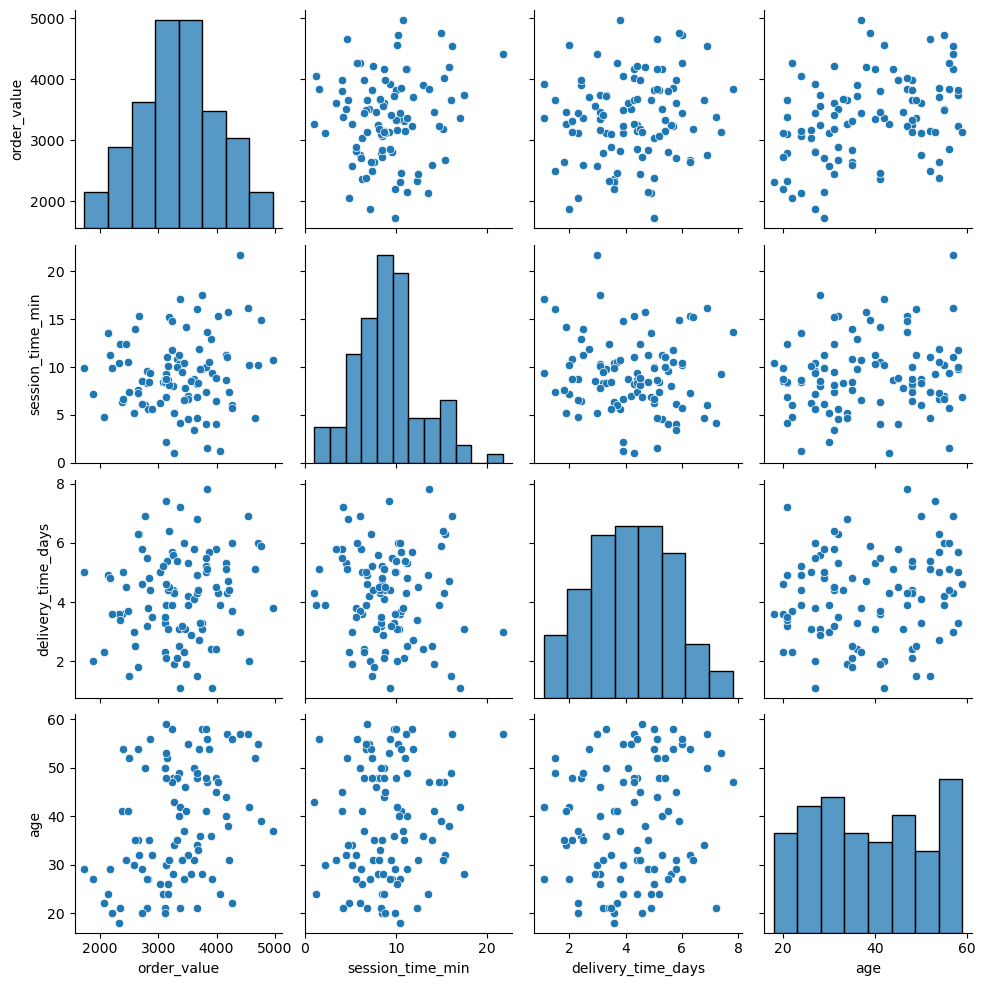

In [23]:
# pair plot
import matplotlib.pyplot as plt
import seaborn as sns

df_s = df[['order_value', 'session_time_min', 'delivery_time_days', 'age']].sample(n=100, random_state=11)
sns.pairplot(df_s)

From the pairplot visualization, there does not appear to be any strong linear relationship between the variables 
(order_value, session_time_min, delivery_time_days, and age). The scatter plots show widely dispersed points 
without a clear upward or downward trend, suggesting weak or no strong correlation among these features.

The diagonal histograms indicate that the variables roughly follow a symmetric distribution, suggesting that 
they may be approximately normally distributed. However, this should be further confirmed using statistical 
tests or distribution plots such as histograms or Q-Q plots.

array([[<Axes: title={'center': 'order_value'}>,
        <Axes: title={'center': 'session_time_min'}>],
       [<Axes: title={'center': 'delivery_time_days'}>, <Axes: >]],
      dtype=object)

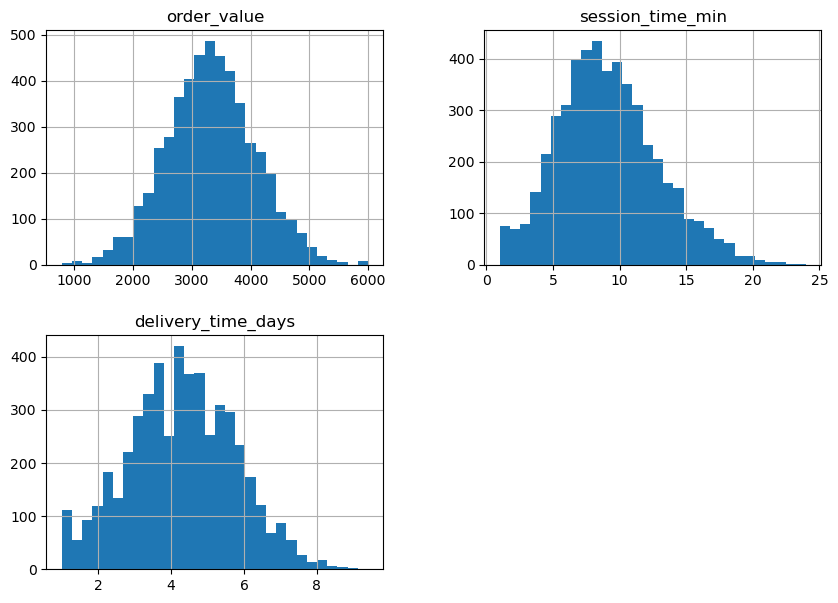

In [32]:
# check the shape
col = ['order_value', 'session_time_min', 'delivery_time_days']
df[col].hist(bins=30, figsize=(10,7))

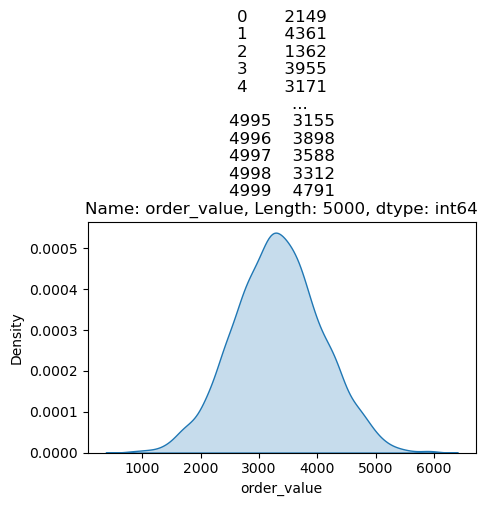

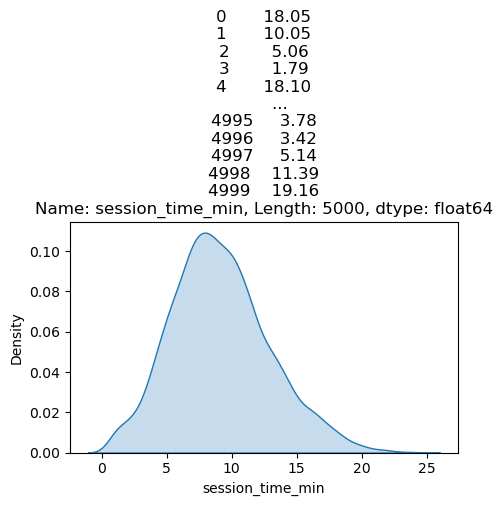

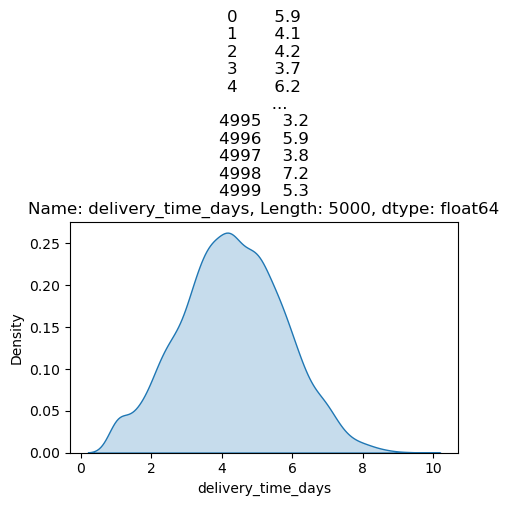

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

for i in col:
    plt.figure(figsize=(5,3))
    sns.kdeplot(df[i], fill=True)
    plt.title(df[i])
    plt.show()

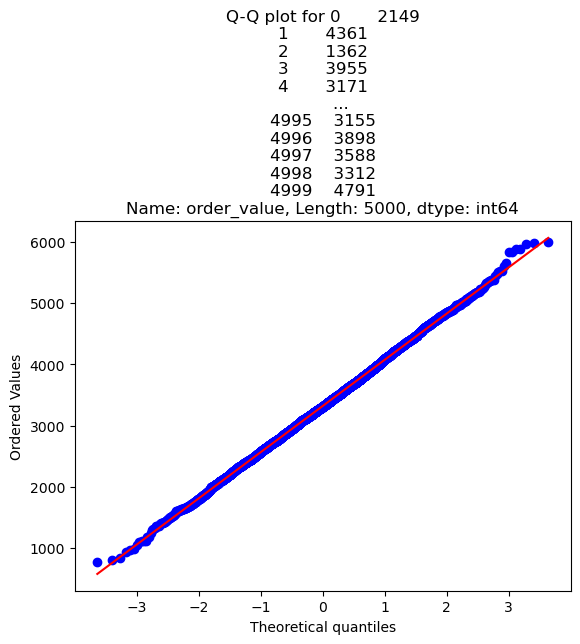

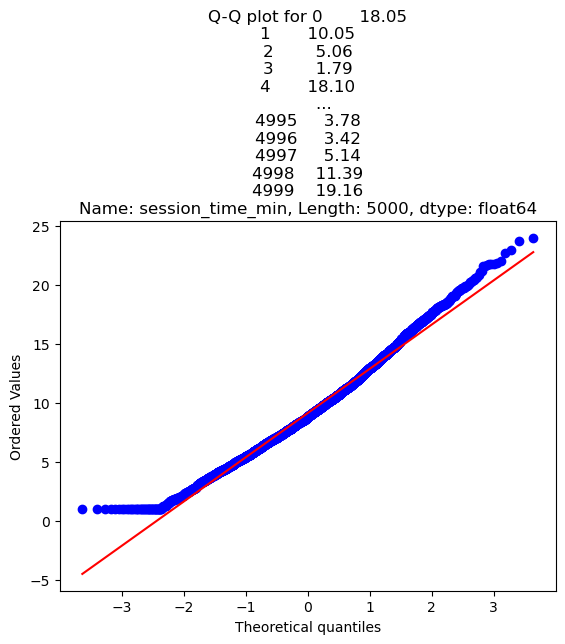

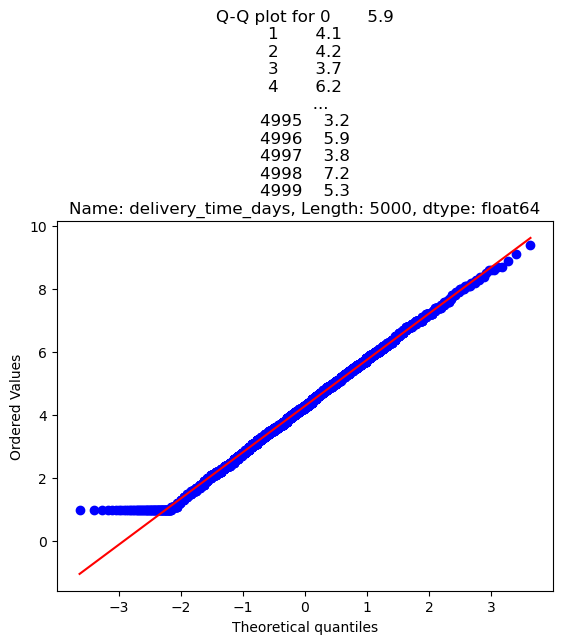

In [41]:
import scipy.stats as stats
import matplotlib.pyplot as plt

for i in col:
    stats.probplot(df[i], dist='norm', plot=plt)
    plt.title(f'Q-Q plot for {df[i]}')
    plt.show()

Distribution Analysis of Numerical Variables
Before running any statistical test, I first wanted to understand how the numbers in my dataset are spread out. To do this, I used four types of charts — histograms, KDE plots, pair plots, and Q-Q plots. Each chart tells me something different about the data.

1. Histogram
What is it?
A histogram is simply a bar chart that shows me how often different values appear. Think of it like this — if I plot all the order values, the bars tell me how many customers ordered in each price range.
What I saw:
order_value — The bars form a shape that looks like a hill, taller in the middle and shorter on both sides. This tells me most customers place orders between ₹2,500 and ₹4,000. Very few people order for very low or very high amounts.
session_time_min — The bars are taller on the left and gradually get shorter toward the right. This means most users spend around 6 to 12 minutes on the app, and only a few users stay for a very long time.
delivery_time_days — The bars are spread fairly evenly. Most orders get delivered in 3 to 6 days, and the distribution looks balanced on both sides.
My takeaway: All three columns have good variety in their values. No column is stuck at one number — the data feels realistic and healthy.

2. KDE Plot
What is it?
A KDE plot is just a smoother version of the histogram. Instead of bars, it draws a smooth curve. It is easier to see the overall shape of the data with this plot.
What I saw:
The curve for order_value looks like a smooth hill — higher in the middle and lower on both sides. This is exactly what a healthy, balanced dataset looks like. The KDE plots confirmed everything I already saw in the histograms.
My takeaway: The smooth curves matched the bar charts, which gave me more confidence that the data is genuine and not distorted.

3. Q-Q Plot
What is it?
Q-Q stands for Quantile-Quantile. I know that sounds technical, but the idea is very simple. This plot helps me check one specific question — does my data follow a normal distribution?
A normal distribution just means the data is balanced — most values sit near the middle, and fewer values sit at the extremes. Think of students' exam scores — most students score somewhere in the middle, very few score extremely low or extremely high. That bell-shaped pattern is called normal distribution.
How to read it:
The red line in the plot represents what perfect normal data would look like. The blue dots represent my actual data. If the blue dots stay close to the red line, my data is close to normal.
What I saw:
order_value — The blue dots follow the red line very closely almost all the way. This tells me order values are approximately normally distributed.
session_time_min — Most dots follow the line well, but at the lower end the dots drift slightly away. This makes sense because session time cannot go below zero — there is a natural floor.
delivery_time_days — Same story. Dots mostly follow the line with small drifts at the edges because delivery time also cannot go below one day.
My takeaway: All three columns are close to normally distributed. The small drifts at the edges are completely expected and nothing to worry about.

Overall Conclusion
After looking at all four charts, I am confident that my dataset is clean, realistic, and ready for hypothesis testing. The values have good variety, the distributions look natural, and the data is close to normally distributed — which is exactly what most statistical tests need to work correctly.

Task 1 — One-Sample T-Test
Business Context
You are a Data Analyst at ShopSmart India.
The logistics team has always claimed:

"Our average delivery time is 5 days — same as the industry standard."

Your manager comes to you and says:

"I keep hearing from customers that deliveries are arriving earlier than expected. Can you actually verify this with data? Is our average delivery time really 5 days or are we genuinely faster?"

In [55]:
df['delivery_time_days'].mean()

np.float64(4.295039999999999)

# T-test One Sample

Null Hypothesis: Average Delivery time is 5 days
Alternative Hypothesis:  Average Delivery time is not 5 days

In [53]:
# import the library for t-test one sample
from scipy.stats import ttest_1samp

# One Sample T-Test
t_stat, p_value = ttest_1samp(df['delivery_time_days'], 5)

print('t-statistic:', t_stat)
print('p-value:', p_value)

t-statistic: -33.97244917808285
p-value: 8.486328716570805e-228


One-Sample T-Test — Analysis
What I checked:
Is our average delivery time actually 5 days like the logistics team claims?
What I found:
Our actual average delivery time from the data is 4.29 days not 5.
Test result:
P-value is nearly 0, which is way below 0.05, so we reject the null hypothesis.
This means the difference is not random. It is real and statistically significant.
The t-statistic is negative (-33.97), which simply means our delivery time is lower than the claimed value of 5 days.
Business conclusion:
ShopSmart is delivering faster than the industry standard. The logistics team's claim of 5 days is outdated. Marketing can use this as a competitive advantage — we are genuinely faster than what we tell our customers.

# T-Test Two Sample

Task 2 — Two-Sample T-Test
Situation:
The marketing team believes — "Female customers spend more per order than male customers."
Your manager says — "prove it with data."

Null Hypothesis: Average order value is same between male an female
Alternative Hypothesis:  Average Delivery time is not same

<Axes: xlabel='gender'>

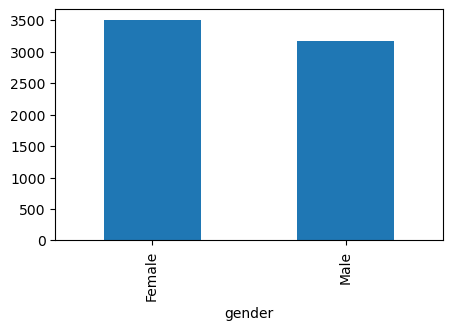

In [60]:
df.groupby('gender')['order_value'].mean().plot(kind='bar', figsize=(5,3))

In [58]:
# import the library for t-test two sample
from scipy.stats import ttest_ind

#defining the groups

# Male Budget
male_budget = df[df['gender'] == 'Male']['order_value'].dropna()
# Female Budget
female_budget = df[df['gender'] == 'Female']['order_value'].dropna()

# Two Sample T-Test
t_stat, p_value = ttest_ind(male_budget, female_budget)

print('t-stat:', t_stat)
print('p-value:', p_value)

t-stat: -15.629924925602852
p-value: 8.401774899329867e-54


Two-Sample T-Test — Analysis
What I checked:
Do female customers spend more per order than male customers?
What I found:
From the bar chart, female customers spend around 3,500 on average vs 3,100 for male customers.
Test result:
P-value is nearly 0 — way below 0.05. So we reject the null hypothesis.
The difference is real, not random chance.
T-statistic is negative (-15.63) which means the first group passed (male) has a lower mean than the second group (female).
Business conclusion:
Female customers spend significantly more than male customers. Marketing should consider targeted campaigns with higher value products for female customers.

# Annova
Task 3 — ANOVA
Situation:
The business team believes — "Order values are different across our 5 cities."
Your manager says — "which city is spending the most and is the difference actually real?"

Null Hypothesis: Order value same across cities
Alternative Hypothesis: Order value not same across cities

<Axes: xlabel='city'>

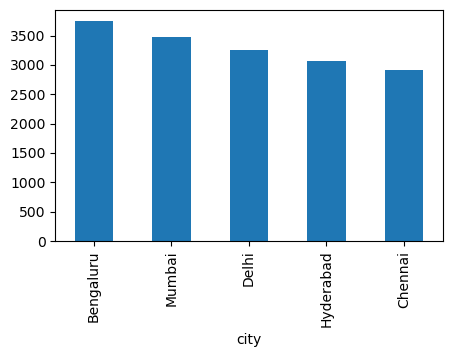

In [66]:
df.groupby('city')['order_value'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(5,3))

In [69]:
subset = df[['city', 'order_value']].dropna()
subset

,city,order_value
0,Chennai,2149
1,Bengaluru,4361
2,Hyderabad,1362
3,Mumbai,3955
4,Delhi,3171
...,...,...
4995,Chennai,3155
4996,Bengaluru,3898
4997,Delhi,3588
4998,Delhi,3312


In [73]:
## creating groups
groups = [j['order_value'] for i,j in subset.groupby('city')]
print(groups)

[1       4361
5       4012
10      4520
11      3180
31      3460
        ... 
4964    3770
4973    3319
4976    4716
4984    3948
4996    3898
Name: order_value, Length: 1004, dtype: int64, 0       2149
7       3320
8       3134
14      3135
15      3095
        ... 
4980    3837
4985    2341
4992    2870
4994    2919
4995    3155
Name: order_value, Length: 863, dtype: int64, 4       3171
6       4700
12      2091
17      3366
22      3593
        ... 
4975    3135
4983    3467
4989    2403
4997    3588
4998    3312
Name: order_value, Length: 1127, dtype: int64, 2       1362
13      2925
18      2505
21      2539
27      3308
        ... 
4969    3811
4974    2335
4988    1695
4990    2200
4991    3181
Name: order_value, Length: 720, dtype: int64, 3       3955
9       4629
24      5603
35      4678
39      4548
        ... 
4982    3872
4986    4629
4987    3162
4993    4296
4999    4791
Name: order_value, Length: 1286, dtype: int64]


In [74]:
# Run Annova Test

# import library for Annova
from scipy.stats import f_oneway

# Annova test
f_stat, p_value = f_oneway(*groups)

print('f-stat:', f_stat)
print('p-value:', p_value)

f-stat: 214.86724207293065
p-value: 2.2791432849938e-170


ANOVA — Analysis Note
What I checked:
Is the difference in average order value across 5 cities real or just random chance?
What I found:
From the bar chart, Bengaluru has the highest average order value, followed by Mumbai, Delhi, Hyderabad, and Chennai at the bottom.
Test result:
P-value is nearly 0 — way below 0.05. So we reject the null hypothesis.
The difference in order values across cities is real and statistically significant.
F-statistic is 214.86 — a very large value, which means the variation between cities is much larger than the variation within each city.

# Chi-Square Test
Task 4 — Chi-Square
Situation:
The product team believes — "The device a customer uses affects whether they convert or not."
Your manager says — "prove it with data."
You have device_type column (Mobile, Desktop, Tablet) and converted column (0 or 1).

Null Hypothesis: The device a customer uses has no effect on conversation
Alternative Hypothesis: The device a customer uses has an effect on conversation

In [78]:
# import library for chi-square test
from scipy.stats import chi2_contingency

# creat the cross tab table
table = pd.crosstab(df['device_type'], df['converted']) # pd.crosstab creates frequency table

# chi-square test
chi2, p_value, dof, expected = chi2_contingency(table)

print('Chi-square statistic:', chi2)
print('p-value:', p_value)
print('Degrees of freedom:', dof)

Chi-square statistic: 12.688604805989547
p-value: 0.0017567278034233734
Degrees of freedom: 2


In [79]:
# conversion rates
df.groupby('device_type')['converted'].value_counts(normalize=True)

device_type  converted
Desktop      0            0.874396
             1            0.125604
Mobile       0            0.908038
             1            0.091962
Tablet       0            0.884470
             1            0.115530
Name: proportion, dtype: float64

In [80]:
# freqency table
table

converted,0,1
device_type,,
Desktop,1267,182
Mobile,2745,278
Tablet,467,61


Chi-Square — Analysis Note
What I checked:
Does the device type a customer uses affect whether they convert or not?
What I found:
Desktop converts at 12.5%, Tablet at 11.5% and Mobile the lowest at 9.2% — despite Mobile having the most users (2745+278 = 3023).
Test result:
P-value = 0.0017 — below 0.05. So we reject the null hypothesis.
The difference in conversion across devices is real, not random chance.
Business conclusion:
Device type does affect conversion. Mobile has the most traffic but the worst conversion rate. The product team should prioritise fixing the mobile checkout experience.

# A/B Test
Task 5 — A/B Test (Z-Test)
Situation:
The product team changed the checkout button colour. Old blue button = A_Control. New orange button = B_Variant.
Your manager says — "did the new orange button actually increase orders or was it just a cosmetic change?"

Null Hypothesis = The button color change did not affect conversion rate.
Alternative Hypothesis = The button color change affect conversion rate.

In [98]:
# Conversion rates
Conversion_rates = df.groupby('experiment_group')['converted'].mean() * 100
Conversion_rates

experiment_group
A_Control     8.929976
B_Variant    11.960944
Name: converted, dtype: float64

In [87]:
# divide group
control = df[df['experiment_group'] == 'A_Control']
variant = df[df['experiment_group'] == 'B_Variant']

In [102]:
# calculate how many users converted (placed an order) in each group.
control_converted = control['converted'].sum()
variant_converted = variant['converted'].sum()

print(control_converted, variant_converted)

227 294


In [103]:
# total number of users in each group.

control_total = control['converted'].count()
variant_total = variant['converted'].count()

print(control_total, variant_total)

2542 2458


In [104]:
# Conversion Rates
# rate = sum * 100 / count (binary)
control_rate = control_converted / control_total
variant_rate = variant_converted / variant_total

print(control_rate, variant_rate)

0.08929976396538158 0.11960943856794141


In [105]:
# Run Z-Test

from statsmodels.stats.proportion import proportions_ztest

success = [control_converted, variant_converted]
nobs = [control_total, variant_total]

z_stat, p_value = proportions_ztest(success, nobs)

print('Z-statistic:', z_stat)
print('P-value:', p_value)

Z-statistic: -3.506998624874197
P-value: 0.00045319149052541887


In [107]:
pd.crosstab(df['experiment_group'], df['converted']) # creates frequency table

converted,0,1
experiment_group,,
A_Control,2315,227
B_Variant,2164,294


In [108]:
# Difference in the rates
(variant_rate * 100) - (control_rate * 100)

np.float64(3.030967460255983)

A/B Test (Z-Test) — Analysis Note
What I checked:
Did the new orange checkout button (B_Variant) convert better than the old blue button (A_Control)?
What I found:
A_Control converted 227 out of 2542 users — a rate of 8.9%.
B_Variant converted 294 out of 2458 users — a rate of 12.0%.
The orange button shows a higher conversion rate from just looking at the numbers.
Test result:
P-value = 0.0004 — way below 0.05. So we reject the null hypothesis.
The difference is real, not random chance.
Z-statistic is negative (-3.50) which means the first group passed (A_Control) has a lower conversion rate than B_Variant.

Business conclusion:
The new orange button genuinely performs better. The product team should permanently replace the old blue button with the orange one across the entire platform. Even a 3% absolute improvement in conversion rate at this scale translates to a meaningful increase in orders.

# Final Business Recommendations

Based on all analyses — delivery performance validation, customer spending behaviour, city-level order value patterns, device conversion analysis, and A/B testing — the following recommendations are proposed for the ShopSmart India product, marketing, and operations teams.

1. Promote Faster Delivery as a Competitive Advantage

The one-sample t-test shows that the actual average delivery time is 4.29 days, significantly lower than the industry benchmark of 5 days.

This means ShopSmart is delivering faster than what customers expect.

Recommendation

Marketing should highlight fast delivery in campaigns such as:

“Average delivery under 5 days”

“Faster than industry standard delivery”

This can increase customer trust and improve conversion rates.

2. Target High-Spending Female Customers

The two-sample t-test confirmed that female customers spend significantly more per order than male customers.

Average order value for female customers is approximately ₹3500, compared to ₹3100 for male customers.

Recommendation

The marketing team should:

Create targeted campaigns for female customers

Promote premium or bundle products

Offer loyalty rewards for repeat female shoppers

This segment has strong potential to increase revenue per customer.

3. Focus Marketing Investment on High-Spending Cities

The ANOVA test confirmed that average order value differs significantly across cities.

Among the five cities analyzed:

Bengaluru shows the highest average order value

Followed by Mumbai and Delhi

Recommendation

The business should prioritize:

Higher marketing budget in Bengaluru and Mumbai

Premium product promotion in high-value cities

Localized offers based on city purchasing behaviour

City-level targeting can significantly improve marketing ROI.

4. Improve Mobile Checkout Experience

The Chi-Square test confirmed that device type significantly affects conversion rates.

Findings:

Desktop conversion rate -12.5%

Tablet conversion rate -11.5%

Mobile conversion rate -9.2%

Despite mobile generating the highest traffic, it converts the worst.

Recommendation

The product team should prioritize mobile checkout optimization, including:

Faster page load time

Simplified checkout flow

Better mobile UI for payment and cart

Improving mobile conversion even slightly can lead to a large increase in orders.

5. Roll Out the Orange Checkout Button Across the Platform

The A/B test shows that the new orange checkout button performs significantly better than the old blue button.

Conversion rates:

A_Control (Blue): -8.9%

B_Variant (Orange): -12.0%

The Z-test confirms that this improvement is statistically significant, not random.

Recommendation

The product team should:

Replace the blue checkout button with the orange version across the entire platform

Continue running future A/B tests for other UI elements

Even a 3% absolute increase in conversion rate can generate a substantial increase in total orders at scale.

Overall Business Impact

By implementing these recommendations, ShopSmart can:

Increase conversion rates

Improve marketing efficiency

Focus on high-value customer segments

Strengthen its competitive advantage in delivery speed

Together, these improvements can drive higher revenue, better customer experience, and stronger long-term growth.